In [ ]:
# RAR Analysis (SPARC)

Reproduzierbare Analyse der Radial Acceleration Relation (RAR) basierend auf SPARC-Daten.

Inhalte:
- globaler RAR-Fit
- HIGH/LOW Regime-Split
- Verbindung zu q-Regimen

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import zipfile
import json
from pathlib import Path
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

ZIP_PATH = "/content/Rotmod_LTG.zip"
Q_PATH   = "/content/q_fit_results.csv"

BASE = Path("/content/rar_project_clean")
ROT  = BASE / "rotmod"
OUT  = BASE / "output"

ROT.mkdir(parents=True, exist_ok=True)
OUT.mkdir(parents=True, exist_ok=True)

print("Setup ok")

Setup ok


In [3]:
with zipfile.ZipFile(ZIP_PATH, "r") as z:
    z.extractall(ROT)

dat_files = sorted(ROT.rglob("*_rotmod.dat"))

print("Dateien:", len(dat_files))

Dateien: 175


In [4]:
cols8 = ["r","Vobs","errV","Vgas","Vdisk","Vbul","extra1","extra2"]

all_dfs = []

for file_path in dat_files:
    name = Path(file_path).stem.replace("_rotmod","")

    df = pd.read_csv(
        file_path,
        sep=r"\s+",
        comment="#",
        header=None,
        names=cols8
    )

    df["galaxy"] = name
    all_dfs.append(df)

all_data = pd.concat(all_dfs, ignore_index=True)

print("OK:", len(all_data))

OK: 3391


In [5]:
rar_data = all_data[["galaxy","r","Vobs","Vgas","Vdisk","Vbul"]].copy()

for col in ["r","Vobs","Vgas","Vdisk","Vbul"]:
    rar_data[col] = pd.to_numeric(rar_data[col], errors="coerce")

rar_data = rar_data.dropna()
rar_data = rar_data[rar_data["r"] > 0]

rar_data["g_obs"] = (rar_data["Vobs"]**2) / rar_data["r"]
rar_data["g_bar"] = (
    rar_data["Vgas"]**2 +
    rar_data["Vdisk"]**2 +
    rar_data["Vbul"]**2
) / rar_data["r"]

rar_data = rar_data[(rar_data["g_obs"] > 0) & (rar_data["g_bar"] > 0)]

print("RAR:", len(rar_data))

RAR: 3391


In [6]:
gbar = rar_data["g_bar"].values
gobs = rar_data["g_obs"].values

log_gbar = np.log10(gbar)
log_gobs = np.log10(gobs)

model = LinearRegression()
model.fit(log_gbar.reshape(-1,1), log_gobs)

from sklearn.metrics import r2_score
y_pred = model.predict(log_gbar.reshape(-1,1))

print("Slope:", model.coef_[0])
print("R²:", r2_score(log_gobs, y_pred))

Slope: 0.6693209257487138
R²: 0.8628156906339599


In [7]:
threshold = rar_data["g_bar"].median()

high_df = rar_data[rar_data["g_bar"] > threshold].copy()
low_df  = rar_data[rar_data["g_bar"] <= threshold].copy()

print("Threshold:", threshold)
print("HIGH Punkte:", len(high_df))
print("LOW Punkte:", len(low_df))

Threshold: 1040.7012128712872
HIGH Punkte: 1695
LOW Punkte: 1696


In [8]:
def fit_simple(df):
    gbar = df["g_bar"].values
    gobs = df["g_obs"].values

    log_gbar = np.log10(gbar)
    log_gobs = np.log10(gobs)

    model = LinearRegression()
    model.fit(log_gbar.reshape(-1,1), log_gobs)

    y_pred = model.predict(log_gbar.reshape(-1,1))
    r2 = r2_score(log_gobs, y_pred)

    return model.coef_[0], model.intercept_, r2

slope_high, intercept_high, r2_high = fit_simple(high_df)
slope_low, intercept_low, r2_low = fit_simple(low_df)

print("HIGH Regime:")
print("Slope:", slope_high)
print("Intercept:", intercept_high)
print("R^2:", r2_high)

print("\nLOW Regime:")
print("Slope:", slope_low)
print("Intercept:", intercept_low)
print("R^2:", r2_low)

HIGH Regime:
Slope: 0.7838505318118982
Intercept: 0.7904077741599682
R^2: 0.8324873863396078

LOW Regime:
Slope: 0.5575500389939766
Intercept: 1.5346827909761127
R^2: 0.3857379547585206


In [17]:
q_df = pd.read_csv(Q_PATH)

q_df["galaxy"] = q_df["filename"].str.replace("_rotmod.dat", "", regex=False)

print(q_df.head())

              filename         p         q       MSE  n_points    galaxy
0   UGCA444_rotmod.dat  1.459703  3.000000  0.003141        36   UGCA444
1   UGCA442_rotmod.dat  2.044649  0.485413  0.000330         8   UGCA442
2   UGCA281_rotmod.dat  1.943306  0.581791  0.000616         7   UGCA281
3  UGC12732_rotmod.dat  0.781112  3.000000  0.001713        16  UGC12732
4  UGC12632_rotmod.dat  1.273916  0.679549  0.001109        15  UGC12632


In [18]:
rar_galaxy = rar_data.groupby("galaxy").agg({
    "g_bar": "median",
    "g_obs": "median"
}).reset_index()

merged = pd.merge(rar_galaxy, q_df, on="galaxy")

print("Merged:", len(merged))
print(merged[["galaxy", "g_bar", "g_obs", "q"]].head())

Merged: 164
   galaxy       g_bar       g_obs         q
0  D564-8   70.437998  224.269608  0.557137
1  D631-7  176.896751  551.860512  0.348323
2  DDO064  294.895393  823.273051  0.274382
3  DDO154  113.391160  524.366678  0.418674
4  DDO161  203.022293  457.917824  0.436825


In [20]:
def classify_q(q):
    if q < 1.2:
        return "Peak"
    elif q > 2.5:
        return "Diffus"
    else:
        return "Transition"

merged["regime_q"] = merged["q"].apply(classify_q)

print(merged["regime_q"].value_counts())

regime_q
Peak          102
Diffus         42
Transition     20
Name: count, dtype: int64


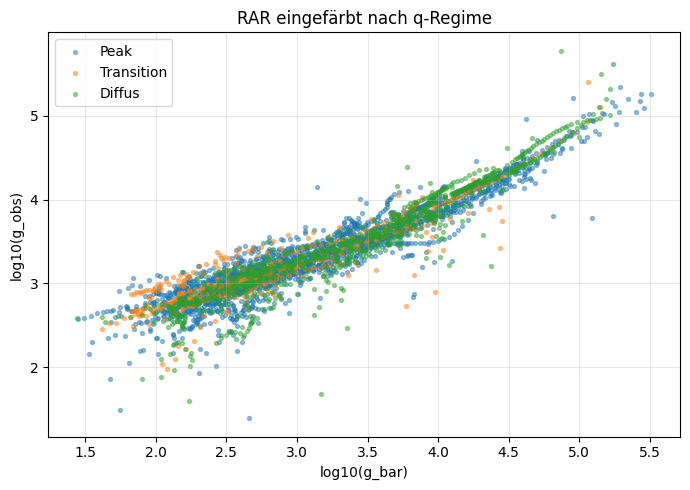

In [21]:
plt.figure(figsize=(7,5))

for regime in ["Peak", "Transition", "Diffus"]:
    galaxies = merged.loc[merged["regime_q"] == regime, "galaxy"]
    subset = rar_data[rar_data["galaxy"].isin(galaxies)]

    plt.scatter(
        np.log10(subset["g_bar"]),
        np.log10(subset["g_obs"]),
        s=8,
        alpha=0.45,
        label=regime
    )

plt.xlabel("log10(g_bar)")
plt.ylabel("log10(g_obs)")
plt.title("RAR eingefärbt nach q-Regime")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("/content/rar_q_overlay.png", dpi=200)
plt.show()

In [22]:
rar_summary = {
    "global_slope": float(model.coef_[0]),
    "global_intercept": float(model.intercept_),
    "global_r2": float(r2_score(log_gobs, y_pred)),
    "n_points": int(len(rar_data)),
    "threshold_gbar": float(threshold),
    "high_slope": float(slope_high),
    "high_intercept": float(intercept_high),
    "high_r2": float(r2_high),
    "high_n": int(len(high_df)),
    "low_slope": float(slope_low),
    "low_intercept": float(intercept_low),
    "low_r2": float(r2_low),
    "low_n": int(len(low_df)),
    "n_galaxies_with_q": int(len(merged)),
    "peak_count": int((merged["regime_q"] == "Peak").sum()),
    "transition_count": int((merged["regime_q"] == "Transition").sum()),
    "diffus_count": int((merged["regime_q"] == "Diffus").sum())
}

import json
with open("/content/rar_summary.json", "w") as f:
    json.dump(rar_summary, f, indent=2)

print(json.dumps(rar_summary, indent=2))

{
  "global_slope": 0.6693209257487138,
  "global_intercept": 1.240936985002111,
  "global_r2": 0.8628156906339599,
  "n_points": 3391,
  "threshold_gbar": 1040.7012128712872,
  "high_slope": 0.7838505318118982,
  "high_intercept": 0.7904077741599682,
  "high_r2": 0.8324873863396078,
  "high_n": 1695,
  "low_slope": 0.5575500389939766,
  "low_intercept": 1.5346827909761127,
  "low_r2": 0.3857379547585206,
  "low_n": 1696,
  "n_galaxies_with_q": 164,
  "peak_count": 102,
  "transition_count": 20,
  "diffus_count": 42
}
